# Chebyshev Policies and the Mountain Car Problem: Reinforcement Learning for Low-dimensional Control Tasks
## Chebyshev PPO @ Pendulum Environment

Does good performance carry over to a more complicated problem setting?  
We utilize the Gymnasium Pendulum environment, which, again, resembles a typical low-dimensional control task but which's observation space has one more dimension.  
We use Chebyshev approximators with PPO instead of REINFORCE in order to mitigate deficiencies of the algorithm for this more complex problem setting.  

Version 1.0   
Date: 2026-01-12  
Current version: hannes.unger@fh-salzburg.ac.at    

# Imports and Definitions

In [ ]:
import os
import time
import multiprocessing as mp
import torch
from utils import exp_run, plot, parallel

from pickleshare import PickleShareDB
db = PickleShareDB('./picklesharedb')

tensorboard_log_dir = "./tensorboard_logs/"
os.makedirs(tensorboard_log_dir, exist_ok=True)

%load_ext autoreload
%autoreload 2

In [ ]:
from envs import custom_gymnasium
from gymnasium.envs.registration import register

deterministic_pendulum_env_name = 'DeterministicPendulum-v1'

# Register the environment
register(
    id=f'{deterministic_pendulum_env_name}',
    entry_point='envs.custom_gymnasium:DeterministicPendulumEnv',  # Or your module path
    max_episode_steps=200,
)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_pendulum_policy(X_flat, Y_flat, Z_flat, actions_flat, vmin=None, vmax=None, ax=None, title=None):
    fig = None
    standalone = False
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        standalone = True
    if vmin is not None and vmax is not None:
        p = ax.scatter(X_flat, Y_flat, Z_flat, c=actions_flat, cmap='viridis', vmin=vmin, vmax=vmax, marker='.', alpha=0.01)
    else:
        p = ax.scatter(X_flat, Y_flat, Z_flat, c=actions_flat, cmap='viridis', marker='.', alpha=0.01)
    ax.set_xlabel(r'$\cos(\theta)$')
    ax.set_ylabel(r'$\sin(\theta)$')
    ax.set_zlabel(r'$\dot{\theta}$')
    ax.set_title(title)
    if standalone:
        cb = plt.colorbar(p, ax=ax, pad=0.15)
        cb.solids.set(alpha=1)  # force solid colorbar
        plt.show()
    else:
        return p

In [7]:
def run_chebyshev_ppo_training(args, numcores):
    start = time.time()
    with mp.Pool(processes=numcores) as pool:
        results = pool.map(exp_run.run_sb3_polyagent_training, args)
    print(f'Execution took {time.time()-start:.0f} seconds')
    return results

In [8]:
def run_chebyshev_ppo_evaluation(results, initial_states, numcores):
    coeffs = [row[2] for row in results]
    pool = parallel.NestablePool(numcores)
    return pool.starmap(exp_run.evaluate_chebyshev_pendulum_deterministic_starting_states_single_coeffs, zip(coeffs, repeat(initial_states), repeat('ppo')))

In [9]:
def plot_training_reward(log_dir, num_policies, name_prefix, seed, title):
    fig, ax1 = plt.subplots() 
    fig.set_figwidth(18)
    fig.set_figheight(8)
    fig.suptitle(title)

    plot.plot_results(tensorboard_dir=log_dir, num_experiments=num_policies, name_prefix=name_prefix, seed=seed, ax=ax1, title=None)

In [10]:
# Since the Pendulum environment does not support setting a deterministic initialization position within the observation space, we have to implement it.  
from envs import custom_gymnasium
from gymnasium.envs.registration import register

deterministic_pendulum_env_name = 'DeterministicPendulum-v1'

def register_deterministic_pendulum_env(deterministic_pendulum_env_name):
    # Register the environment
    register(
        id=f'{deterministic_pendulum_env_name}',
        entry_point='envs.custom_gymnasium:DeterministicPendulumEnv',  
        max_episode_steps=200,
    )

In [11]:
from collections import defaultdict

def summarize_rewards(results):
    """
    Computes min, mean, and max rewards for each distinct algorithm.
    
    Args:
        results (list): A list of entries, where each entry is of the form:
                        [algorithm_name (str), array (np.ndarray), reward (float)]
    
    Returns:
        dict: A dictionary with algorithm names as keys and a dict of stats:
              {'min': ..., 'mean': ..., 'max': ...}
    """
    rewards_by_algo = defaultdict(list)

    # Collect rewards per algorithm
    for algo, _, reward in results:
        rewards_by_algo[algo].append(reward)

    # Compute stats
    summary = {}
    for algo, rewards in rewards_by_algo.items():
        rewards = np.array(rewards)
        summary[algo] = {
            'min': np.min(rewards),
            'mean': np.mean(rewards),
            'max': np.max(rewards),
            'std': np.std(rewards)
        }
    
    return summary

In [12]:
def hyperparameter_training_run(tensorboard_log_dir, run_no=1, degree=6, n_steps = 2048, batch_size = 64, n_epochs = 1, learning_rate = 0.001, n_timesteps=400_000):
    tensorboard_dir = f'{tensorboard_log_dir}ppo_pendulum_{run_no}'

    params = {'algo': 'ppo', 'learning_rate': learning_rate, 'steps': n_timesteps, 'env_name': env_name, 'tensorboard_log_dir': tensorboard_dir, 'name': name_prefix_chebyshev, 'seed': seed,          
            'clip_range': clip_range, 'clip_range_vf': clip_range_vf, 'n_steps': n_steps, 'n_epochs': n_epochs, 'batch_size': batch_size, 'degree': degree}

    args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=params, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
    return run_chebyshev_ppo_training(args, num_cores)

# Training

In [13]:
# hyperparameters adapted from https://huggingface.co/sb3/ars-Pendulum-v1
env_name = "Pendulum-v1"
tensorboard_dir = tensorboard_log_dir + "ppo_pendulum"
learning_rate = 0.001 # default 0.0003
degree=6 # as seen with ARS, degrees 3 - 8 all seem to perform well. With REINFORCE, performance drops with rising degree. 
n_steps = 2048 # default = 2048
batch_size = 1024 # default = 64
n_epochs = 1 # default = 10
clip_range = 0.4 # default = 0.2
clip_range_vf = 0.4 # default = None
use_fixed_std_schedule = False 

n_timesteps = 400_000

num_policies = mp.cpu_count()
name_prefix_chebyshev = 'pendulum_ch-ppo_'
seed = 0
num_cores=mp.cpu_count()

params = {'algo': 'ppo', 'learning_rate': learning_rate, 'steps': n_timesteps, 'env_name': env_name, 'tensorboard_log_dir': tensorboard_dir, 'name': name_prefix_chebyshev, 'seed': seed,          
          'clip_range': clip_range, 'clip_range_vf': clip_range_vf, 'n_steps': n_steps, 'n_epochs': n_epochs, 'batch_size': batch_size, 'degree': degree}

In [ ]:
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=params, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ppo_20260112'] = run_chebyshev_ppo_training(args, num_cores)

Execution took 70 minutes

In [ ]:
tensorboard_dir = tensorboard_log_dir + "ppo_pendulum_2"
degree=3

params = {'algo': 'ppo', 'learning_rate': learning_rate, 'steps': n_timesteps, 'env_name': env_name, 'tensorboard_log_dir': tensorboard_dir, 'name': name_prefix_chebyshev, 'seed': seed,          
          'clip_range': clip_range, 'clip_range_vf': clip_range_vf, 'n_steps': n_steps, 'n_epochs': n_epochs, 'batch_size': batch_size, 'degree': degree}

In [ ]:
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=params, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ppo_20260112_deg3'] = run_chebyshev_ppo_training(args, num_cores)

Experiment took 47 minutes

In [ ]:
tensorboard_dir = tensorboard_log_dir + "ppo_pendulum_3"
degree=6
n_steps = 2048 # default = 2048
batch_size = 64 # default = 64
n_epochs = 1 # default = 10

params = {'algo': 'ppo', 'learning_rate': learning_rate, 'steps': n_timesteps, 'env_name': env_name, 'tensorboard_log_dir': tensorboard_dir, 'name': name_prefix_chebyshev, 'seed': seed,          
          'clip_range': clip_range, 'clip_range_vf': clip_range_vf, 'n_steps': n_steps, 'n_epochs': n_epochs, 'batch_size': batch_size, 'degree': degree}

args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=params, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)
db['pendulum_sb3_chebyshev_ppo_20260112_3'] = run_chebyshev_ppo_training(args, num_cores)

Experiment took 67 minutes

#### Hyperparameter search for CH-PPO: Sweep on parameters affecting rollout size/no. of gradient updates per rollout / learning rate

In [ ]:
db['pendulum_sb3_chebyshev_ppo_20260112_4'] = hyperparameter_training_run(tensorboard_log_dir, run_no=4, degree=6, n_steps = 2048, batch_size = 64, n_epochs = 5, learning_rate=0.001)
db['pendulum_sb3_chebyshev_ppo_20260112_5'] = hyperparameter_training_run(tensorboard_log_dir, run_no=5, degree=6, n_steps = 2048, batch_size = 64, n_epochs = 1, learning_rate=0.0003)
db['pendulum_sb3_chebyshev_ppo_20260112_6'] = hyperparameter_training_run(tensorboard_log_dir, run_no=6, degree=6, n_steps = 2048, batch_size = 64, n_epochs = 5, learning_rate=0.0003)

Run took 374 minutes

In [ ]:
db['pendulum_sb3_chebyshev_ppo_20260112_7'] = hyperparameter_training_run(tensorboard_log_dir, run_no=7, degree=6, n_steps = 2048, batch_size = 32, n_epochs = 1, learning_rate=0.001)
db['pendulum_sb3_chebyshev_ppo_20260112_8'] = hyperparameter_training_run(tensorboard_log_dir, run_no=8, degree=6, n_steps = 2048, batch_size = 32, n_epochs = 5, learning_rate=0.001)
db['pendulum_sb3_chebyshev_ppo_20260112_9'] = hyperparameter_training_run(tensorboard_log_dir, run_no=9, degree=6, n_steps = 2048, batch_size = 32, n_epochs = 1, learning_rate=0.0003)
db['pendulum_sb3_chebyshev_ppo_20260112_10'] = hyperparameter_training_run(tensorboard_log_dir, run_no=10, degree=6, n_steps = 2048, batch_size = 32, n_epochs = 5, learning_rate=0.0003)

Run took 438 minutes

In [ ]:
db['pendulum_sb3_chebyshev_ppo_20260112_11'] = hyperparameter_training_run(tensorboard_log_dir, run_no=11, degree=6, n_steps = 4096, batch_size = 64, n_epochs = 1, learning_rate=0.001)
db['pendulum_sb3_chebyshev_ppo_20260112_12'] = hyperparameter_training_run(tensorboard_log_dir, run_no=12, degree=6, n_steps = 4096, batch_size = 64, n_epochs = 5, learning_rate=0.001)
db['pendulum_sb3_chebyshev_ppo_20260112_13'] = hyperparameter_training_run(tensorboard_log_dir, run_no=13, degree=6, n_steps = 4096, batch_size = 64, n_epochs = 1, learning_rate=0.0003)
db['pendulum_sb3_chebyshev_ppo_20260112_14'] = hyperparameter_training_run(tensorboard_log_dir, run_no=14, degree=6, n_steps = 4096, batch_size = 64, n_epochs = 5, learning_rate=0.0003)

Run took 438 minutes

In [ ]:
db['pendulum_sb3_chebyshev_ppo_20260112_15'] = hyperparameter_training_run(tensorboard_log_dir, run_no=15, degree=6, n_steps = 512, batch_size = 32, n_epochs = 1, learning_rate=0.001)
db['pendulum_sb3_chebyshev_ppo_20260112_16'] = hyperparameter_training_run(tensorboard_log_dir, run_no=16, degree=6, n_steps = 512, batch_size = 32, n_epochs = 5, learning_rate=0.001)
db['pendulum_sb3_chebyshev_ppo_20260112_17'] = hyperparameter_training_run(tensorboard_log_dir, run_no=17, degree=6, n_steps = 512, batch_size = 32, n_epochs = 1, learning_rate=0.0003)
db['pendulum_sb3_chebyshev_ppo_20260112_18'] = hyperparameter_training_run(tensorboard_log_dir, run_no=18, degree=6, n_steps = 512, batch_size = 32, n_epochs = 5, learning_rate=0.0003)

Run took 436 minutes

In [33]:
# Taken from eval summary in next chapter, run no.6 has the best combined mean reward. 
# Slightly increasing learning rate since other runs show higher max reward and increasing no. of epochs to default parameter
learning_rate = 0.0006 # default 0.0003
n_steps = 2048 # default = 2048
batch_size = 64 # default = 64
n_epochs = 10 # default = 10

#### Different polynomial degrees for determined parameters 

In [ ]:
db['pendulum_sb3_chebyshev_ppo_20260112_19'] = hyperparameter_training_run(tensorboard_log_dir, run_no=19, degree=3, n_steps = n_steps, batch_size = batch_size, n_epochs = n_epochs, learning_rate=learning_rate)
db['pendulum_sb3_chebyshev_ppo_20260112_20'] = hyperparameter_training_run(tensorboard_log_dir, run_no=20, degree=4, n_steps = n_steps, batch_size = batch_size, n_epochs = n_epochs, learning_rate=learning_rate)
db['pendulum_sb3_chebyshev_ppo_20260112_21'] = hyperparameter_training_run(tensorboard_log_dir, run_no=21, degree=5, n_steps = n_steps, batch_size = batch_size, n_epochs = n_epochs, learning_rate=learning_rate)
db['pendulum_sb3_chebyshev_ppo_20260112_22'] = hyperparameter_training_run(tensorboard_log_dir, run_no=22, degree=7, n_steps = n_steps, batch_size = batch_size, n_epochs = n_epochs, learning_rate=learning_rate)
db['pendulum_sb3_chebyshev_ppo_20260112_23'] = hyperparameter_training_run(tensorboard_log_dir, run_no=23, degree=8, n_steps = n_steps, batch_size = batch_size, n_epochs = n_epochs, learning_rate=learning_rate)

Run took 1343 minutes

In [56]:
# Taken from eval summary in next chapter, degree 5 shows the best max reward, but high variance with other agents 
degree = 5

In [ ]:
# repeating run 11 with degree 5, which has shown the best mean reward over all agents with degree 3
db['pendulum_sb3_chebyshev_ppo_20260112_24'] = hyperparameter_training_run(tensorboard_log_dir, run_no=24, degree=degree, n_steps = 4096, batch_size = 64, n_epochs = 1, learning_rate=0.001)

Experiment took 60 minutes

In [11]:
# # Mediocre results, returning to previous hyperparams but decreasing learning rate and no. of epochs to more stable result of run 6
degree = 5
learning_rate = 0.0004 # default 0.0003
n_steps = 2048 # default = 2048
batch_size = 64 # default = 64
n_epochs = 5 # default = 10

In [ ]:
db['pendulum_sb3_chebyshev_ppo_20260112_25'] = hyperparameter_training_run(tensorboard_log_dir, run_no=25, degree=degree, n_steps = n_steps, batch_size = batch_size, n_epochs = n_epochs, learning_rate=learning_rate)

Experiment took 137 minutes

#### Increasing / decreasing total_timesteps for determined parameters

In [ ]:
db['pendulum_sb3_chebyshev_ppo_20260112_26'] = hyperparameter_training_run(tensorboard_log_dir, run_no=26, degree=degree, n_steps = n_steps, batch_size = batch_size, n_epochs = n_epochs, learning_rate=learning_rate, n_timesteps=200_000)
db['pendulum_sb3_chebyshev_ppo_20260112_27'] = hyperparameter_training_run(tensorboard_log_dir, run_no=27, degree=degree, n_steps = n_steps, batch_size = batch_size, n_epochs = n_epochs, learning_rate=learning_rate, n_timesteps=500_000)
db['pendulum_sb3_chebyshev_ppo_20260112_28'] = hyperparameter_training_run(tensorboard_log_dir, run_no=28, degree=degree, n_steps = n_steps, batch_size = batch_size, n_epochs = n_epochs, learning_rate=learning_rate, n_timesteps=700_000)
db['pendulum_sb3_chebyshev_ppo_20260112_29'] = hyperparameter_training_run(tensorboard_log_dir, run_no=29, degree=degree, n_steps = n_steps, batch_size = batch_size, n_epochs = n_epochs, learning_rate=learning_rate, n_timesteps=1_000_000)

Experiment took 820 minutes

In [ ]:
# Mediocre results, returning to run 11, since it provides one of the best overall results
db['pendulum_sb3_chebyshev_ppo_20260112_30'] = hyperparameter_training_run(tensorboard_log_dir, run_no=30, degree=6, n_steps = 8192, batch_size = 64, n_epochs = 1, learning_rate=0.001, n_timesteps=n_timesteps) # further increasing n_steps
db['pendulum_sb3_chebyshev_ppo_20260112_31'] = hyperparameter_training_run(tensorboard_log_dir, run_no=31, degree=6, n_steps = 4096, batch_size = 128, n_epochs = 1, learning_rate=0.001, n_timesteps=n_timesteps) # further increasing batch_size instead
db['pendulum_sb3_chebyshev_ppo_20260112_32'] = hyperparameter_training_run(tensorboard_log_dir, run_no=32, degree=6, n_steps = 8192, batch_size = 128, n_epochs = 1, learning_rate=0.001, n_timesteps=n_timesteps) # further increasing botch

Experiment took 200 minutes

## Plotting training performance

In [ ]:
plot_training_reward(tensorboard_dir, num_policies, name_prefix_chebyshev, seed, title=f'PPO @ {env_name}\nMin, mean and max reward over episodes\n{num_policies} policies with distinct starting seeds trained for {n_timesteps} steps\nChebyshev (max.deg {degree})')

# Evaluation

In [24]:
# Equidistant points for each dimension
n_points_per_dim = 50
angles = np.linspace(-np.pi, np.pi, n_points_per_dim)
velocities = np.linspace(-1, 1, n_points_per_dim)
angle_grid, velocity_grid = np.meshgrid(angles, velocities)
initial_states = np.column_stack([angle_grid.ravel(), velocity_grid.ravel()])

print(f"Total initial states: {len(initial_states)}") 
print(f"First few states:\n{initial_states[:5]}")

Total initial states: 2500
First few states:
[[-3.14159265 -1.        ]
 [-3.01336438 -1.        ]
 [-2.88513611 -1.        ]
 [-2.75690784 -1.        ]
 [-2.62867957 -1.        ]]


In [ ]:
start = time.time()
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112'], initial_states=initial_states, numcores=num_cores)
print(f'Execution took {time.time()-start:.0f} seconds')
db['pendulum_chebyshev_ppo_eval_results_20260112'] = [r[0] for r in results] # flatten results

Execution took 15 minutes

In [ ]:
start = time.time()
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_deg3'], initial_states=initial_states, numcores=num_cores)
print(f'Execution took {time.time()-start:.0f} seconds')
db['pendulum_chebyshev_ppo_eval_results_20260112_deg3'] = [r[0] for r in results]

In [ ]:
start = time.time()
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_3'], initial_states=initial_states, numcores=num_cores)
print(f'Execution took {time.time()-start:.0f} seconds')
db['pendulum_chebyshev_ppo_eval_results_20260112_3'] = [r[0] for r in results]

In [ ]:
start = time.time()
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_4'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_4'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_5'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_5'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_6'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_6'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_7'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_7'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_8'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_8'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_9'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_9'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_10'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_10'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_11'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_11'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_12'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_12'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_13'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_13'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_14'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_14'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_15'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_15'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_16'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_16'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_17'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_17'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_18'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_18'] = [r[0] for r in results]
print(f'Execution took {time.time()-start:.0f} seconds')

Ran 197 minutes

In [ ]:
start = time.time()
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_19'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_19'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_20'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_20'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_21'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_21'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_22'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_22'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_23'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_23'] = [r[0] for r in results]
print(f'Execution took {time.time()-start:.0f} seconds')

Ran 64 minutes

In [ ]:
start = time.time()
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_24'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_24'] = [r[0] for r in results]
print(f'Execution took {time.time()-start:.0f} seconds')

Took 16 minutes

In [ ]:
start = time.time()
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_25'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_25'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_26'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_26'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_27'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_27'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_28'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_28'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_29'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_29'] = [r[0] for r in results]
print(f'Execution took {time.time()-start:.0f} seconds')

Experiment ran 61 minutes

In [ ]:
start = time.time()
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_30'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_30'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_31'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_31'] = [r[0] for r in results]
results = run_chebyshev_ppo_evaluation(results=db['pendulum_sb3_chebyshev_ppo_20260112_32'], initial_states=initial_states, numcores=num_cores)
db['pendulum_chebyshev_ppo_eval_results_20260112_32'] = [r[0] for r in results]
print(f'Execution took {time.time()-start:.0f} seconds')

Experiment ran 45 minutes

#### Print evaluation result overviews

In [19]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260112_1320_6_164899 -216.4698  0       
2      pendulum_ch-ppo__20260112_1320_6_296333 -229.1225  0       
3      pendulum_ch-ppo__20260112_1320_6_503844 -232.4483  0       
4      pendulum_ch-ppo__20260112_1320_5_949590 -234.9175  0       
5      pendulum_ch-ppo__20260112_1320_6_047829 -245.6911  0       

            Combined Mean Reward of Top Results             
Mean reward: -231.7299


In [16]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_deg3']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_deg3']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      mountaincar_ch-ppo__20260112_1207_3_661980 -210.7470  0       
2      mountaincar_ch-ppo__20260112_1207_3_705498 -219.0564  0       
3      mountaincar_ch-ppo__20260112_1207_3_679311 -254.7509  0       
4      mountaincar_ch-ppo__20260112_1207_3_427954 -265.8890  0       
5      mountaincar_ch-ppo__20260112_1207_3_602117 -288.0720  0       

            Combined Mean Reward of Top Results             
Mean reward: -247.7030


In [58]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_3']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_3']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260113_1301_36_725034 -181.6877  0       
2      pendulum_ch-ppo__20260113_1301_36_365402 -187.2275  0       
3      pendulum_ch-ppo__20260113_1301_36_204196 -190.3245  0       
4      pendulum_ch-ppo__20260113_1301_36_990501 -206.1796  0       
5      pendulum_ch-ppo__20260113_1301_36_280402 -255.3506  0       

            Combined Mean Reward of Top Results             
Mean reward: -204.1540


In [17]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_4']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_4']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260113_1632_38_988569 -170.6680  0       
2      pendulum_ch-ppo__20260113_1632_39_410986 -194.3288  0       
3      pendulum_ch-ppo__20260113_1632_38_955579 -266.7154  0       
4      pendulum_ch-ppo__20260113_1632_39_336285 -652.6176  0       
5      pendulum_ch-ppo__20260113_1632_38_964875 -781.7687  0       

            Combined Mean Reward of Top Results             
Mean reward: -413.2197


In [18]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_5']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_5']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260113_1909_27_314808 -179.7505  0       
2      pendulum_ch-ppo__20260113_1909_27_381769 -192.6501  0       
3      pendulum_ch-ppo__20260113_1909_27_394417 -197.8459  0       
4      pendulum_ch-ppo__20260113_1909_27_369270 -200.8051  0       
5      pendulum_ch-ppo__20260113_1909_27_421590 -202.4224  0       

            Combined Mean Reward of Top Results             
Mean reward: -194.6948


In [19]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_6']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_6']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260113_2011_11_849240 -181.3427  0       
2      pendulum_ch-ppo__20260113_2011_11_842720 -183.8957  0       
3      pendulum_ch-ppo__20260113_2011_11_867979 -189.4905  0       
4      pendulum_ch-ppo__20260113_2011_11_760960 -202.4944  0       
5      pendulum_ch-ppo__20260113_2011_11_843767 -214.7751  0       

            Combined Mean Reward of Top Results             
Mean reward: -194.3997


In [20]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_7']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_7']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260113_2247_21_575653 -177.7437  0       
2      pendulum_ch-ppo__20260113_2247_21_542572 -209.0737  0       
3      pendulum_ch-ppo__20260113_2247_21_542572 -214.1372  0       
4      pendulum_ch-ppo__20260113_2247_21_569577 -224.4930  0       
5      pendulum_ch-ppo__20260113_2247_21_439832 -288.2918  0       

            Combined Mean Reward of Top Results             
Mean reward: -222.7479


In [21]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_8']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_8']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260113_2349_26_615865 -654.9610  0       
2      pendulum_ch-ppo__20260113_2349_26_637916 -819.7257  0       
3      pendulum_ch-ppo__20260113_2349_26_589613 -855.9871  0       
4      pendulum_ch-ppo__20260113_2349_26_626546 -894.7642  0       
5      pendulum_ch-ppo__20260113_2349_26_572373 -942.9786  0       

            Combined Mean Reward of Top Results             
Mean reward: -833.6833


In [22]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_9']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_9']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260114_0226_18_783231 -191.3490  0       
2      pendulum_ch-ppo__20260114_0226_18_778081 -212.3752  0       
3      pendulum_ch-ppo__20260114_0226_18_712048 -263.5640  0       
4      pendulum_ch-ppo__20260114_0226_18_789483 -270.4784  0       
5      pendulum_ch-ppo__20260114_0226_18_675266 -292.9940  0       

            Combined Mean Reward of Top Results             
Mean reward: -246.1521


In [23]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_10']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_10']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260114_0328_22_603322 -170.4237  0       
2      pendulum_ch-ppo__20260114_0328_22_604067 -213.0481  0       
3      pendulum_ch-ppo__20260114_0328_22_541557 -276.7119  0       
4      pendulum_ch-ppo__20260114_0328_22_645640 -465.9047  0       
5      pendulum_ch-ppo__20260114_0328_22_595854 -511.9905  0       

            Combined Mean Reward of Top Results             
Mean reward: -327.6158


In [24]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_11']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_11']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260114_0605_36_292128 -168.4704  0       
2      pendulum_ch-ppo__20260114_0605_36_292507 -173.3687  0       
3      pendulum_ch-ppo__20260114_0605_36_237863 -178.7410  0       
4      pendulum_ch-ppo__20260114_0605_36_282396 -214.6033  0       
5      pendulum_ch-ppo__20260114_0605_36_216000 -241.6403  0       

            Combined Mean Reward of Top Results             
Mean reward: -195.3648


In [25]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_12']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_12']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260114_0707_56_146514 -174.8530  0       
2      pendulum_ch-ppo__20260114_0707_56_180403 -526.4946  0       
3      pendulum_ch-ppo__20260114_0707_56_144846 -566.1635  0       
4      pendulum_ch-ppo__20260114_0707_56_156406 -572.8796  0       
5      pendulum_ch-ppo__20260114_0707_56_141258 -629.3492  0       

            Combined Mean Reward of Top Results             
Mean reward: -493.9480


In [26]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_13']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_13']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260114_0945_17_425724 -181.3308  0       
2      pendulum_ch-ppo__20260114_0945_17_382937 -195.8071  0       
3      pendulum_ch-ppo__20260114_0945_17_408837 -198.2024  0       
4      pendulum_ch-ppo__20260114_0945_17_408776 -202.4505  0       
5      pendulum_ch-ppo__20260114_0945_17_392977 -203.9279  0       

            Combined Mean Reward of Top Results             
Mean reward: -196.3438


In [27]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_14']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_14']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260114_1047_22_280624 -175.2664  0       
2      pendulum_ch-ppo__20260114_1047_22_285992 -188.2254  0       
3      pendulum_ch-ppo__20260114_1047_22_211638 -199.9447  0       
4      pendulum_ch-ppo__20260114_1047_22_259686 -200.6860  0       
5      pendulum_ch-ppo__20260114_1047_22_309461 -233.6840  0       

            Combined Mean Reward of Top Results             
Mean reward: -199.5613


In [28]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_15']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_15']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260114_1324_9_458528 -375.9550  0       
2      pendulum_ch-ppo__20260114_1324_9_395981 -501.7840  0       
3      pendulum_ch-ppo__20260114_1324_9_408681 -638.7512  0       
4      pendulum_ch-ppo__20260114_1324_9_427691 -702.9310  0       
5      pendulum_ch-ppo__20260114_1324_9_421316 -742.0401  0       

            Combined Mean Reward of Top Results             
Mean reward: -592.2923


In [29]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_16']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_16']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260114_1426_17_451967 -290.8857  0       
2      pendulum_ch-ppo__20260114_1426_17_439625 -407.8923  0       
3      pendulum_ch-ppo__20260114_1426_17_408363 -843.2432  0       
4      pendulum_ch-ppo__20260114_1426_17_481936 -908.9009  0       
5      pendulum_ch-ppo__20260114_1426_17_475298 -949.9047  0       

            Combined Mean Reward of Top Results             
Mean reward: -680.1654


In [30]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_17']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_17']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260114_1702_38_722661 -414.2538  0       
2      pendulum_ch-ppo__20260114_1702_38_746366 -420.5758  0       
3      pendulum_ch-ppo__20260114_1702_38_734762 -477.0999  0       
4      pendulum_ch-ppo__20260114_1702_38_746138 -491.6431  0       
5      pendulum_ch-ppo__20260114_1702_38_712805 -561.2581  0       

            Combined Mean Reward of Top Results             
Mean reward: -472.9662


In [31]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_18']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_18']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260114_1804_33_033008 -431.1305  0       
2      pendulum_ch-ppo__20260114_1804_33_001214 -506.9532  0       
3      pendulum_ch-ppo__20260114_1804_32_912175 -572.9527  0       
4      pendulum_ch-ppo__20260114_1804_33_030948 -768.9825  0       
5      pendulum_ch-ppo__20260114_1804_32_872277 -819.0411  0       

            Combined Mean Reward of Top Results             
Mean reward: -619.8120


In [36]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_19']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_19']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260115_0810_35_105695 -456.1978  0       
2      pendulum_ch-ppo__20260115_0810_35_624138 -519.2585  0       
3      pendulum_ch-ppo__20260115_0810_35_664226 -539.4203  0       
4      pendulum_ch-ppo__20260115_0810_35_103864 -574.0945  0       
5      pendulum_ch-ppo__20260115_0810_35_228465 -591.1456  0       

            Combined Mean Reward of Top Results             
Mean reward: -536.0233


In [37]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_20']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_20']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260115_1120_16_832911 -614.3094  0       
2      pendulum_ch-ppo__20260115_1120_16_837466 -639.3268  0       
3      pendulum_ch-ppo__20260115_1120_16_775419 -651.1667  0       
4      pendulum_ch-ppo__20260115_1120_16_873915 -662.4307  0       
5      pendulum_ch-ppo__20260115_1120_16_841216 -677.4952  0       

            Combined Mean Reward of Top Results             
Mean reward: -648.9457


In [38]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_21']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_21']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260115_1500_56_793369 -162.7458  0       
2      pendulum_ch-ppo__20260115_1500_56_721449 -601.9087  0       
3      pendulum_ch-ppo__20260115_1500_56_627385 -709.9721  0       
4      pendulum_ch-ppo__20260115_1500_56_667839 -737.3759  0       
5      pendulum_ch-ppo__20260115_1500_56_705670 -738.8522  0       

            Combined Mean Reward of Top Results             
Mean reward: -590.1709


In [39]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_22']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_22']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260115_1910_59_193675 -179.5098  0       
2      pendulum_ch-ppo__20260115_1910_59_593266 -466.6257  0       
3      pendulum_ch-ppo__20260115_1910_59_427443 -555.1244  0       
4      pendulum_ch-ppo__20260115_1910_59_666406 -633.0074  0       
5      pendulum_ch-ppo__20260115_1910_59_166812 -677.8140  0       

            Combined Mean Reward of Top Results             
Mean reward: -502.4163


In [40]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_23']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_23']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260116_0031_31_414931 -658.3069  0       
2      pendulum_ch-ppo__20260116_0031_31_559472 -691.7201  0       
3      pendulum_ch-ppo__20260116_0031_31_547459 -716.5810  0       
4      pendulum_ch-ppo__20260116_0031_31_530671 -724.3420  0       
5      pendulum_ch-ppo__20260116_0031_31_340295 -790.5470  0       

            Combined Mean Reward of Top Results             
Mean reward: -716.2994


In [59]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_24']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_24']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260116_0831_54_140965 -187.9107  0       
2      pendulum_ch-ppo__20260116_0831_54_485094 -229.7832  0       
3      pendulum_ch-ppo__20260116_0831_54_457506 -243.5589  0       
4      pendulum_ch-ppo__20260116_0831_54_812302 -271.2942  0       
5      pendulum_ch-ppo__20260116_0831_54_521241 -280.2434  0       

            Combined Mean Reward of Top Results             
Mean reward: -242.5581


In [17]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_25']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_25']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260116_1430_22_261290 -330.6394  0       
2      pendulum_ch-ppo__20260116_1430_22_312300 -392.2233  0       
3      pendulum_ch-ppo__20260116_1430_22_330836 -413.2393  0       
4      pendulum_ch-ppo__20260116_1430_22_921020 -453.7451  0       
5      pendulum_ch-ppo__20260116_1430_22_905558 -489.4323  0       

            Combined Mean Reward of Top Results             
Mean reward: -415.8559


In [18]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_26']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_26']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260116_1648_18_063042 -201.2371  0       
2      pendulum_ch-ppo__20260116_1648_18_101990 -235.1647  0       
3      pendulum_ch-ppo__20260116_1648_18_145017 -273.5000  0       
4      pendulum_ch-ppo__20260116_1648_18_167470 -392.3051  0       
5      pendulum_ch-ppo__20260116_1648_18_154229 -508.8015  0       

            Combined Mean Reward of Top Results             
Mean reward: -322.2017


In [19]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_27']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_27']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260116_1757_21_412895 -336.5874  0       
2      pendulum_ch-ppo__20260116_1757_21_411325 -453.4442  0       
3      pendulum_ch-ppo__20260116_1757_21_442382 -461.8471  0       
4      pendulum_ch-ppo__20260116_1757_21_361388 -479.2283  0       
5      pendulum_ch-ppo__20260116_1757_21_411847 -517.4000  0       

            Combined Mean Reward of Top Results             
Mean reward: -449.7014


In [20]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_28']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_28']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260116_2049_45_815574 -193.2621  0       
2      pendulum_ch-ppo__20260116_2049_45_825774 -239.0777  0       
3      pendulum_ch-ppo__20260116_2049_45_872579 -248.9088  0       
4      pendulum_ch-ppo__20260116_2049_45_814378 -305.3944  0       
5      pendulum_ch-ppo__20260116_2049_45_824651 -370.6085  0       

            Combined Mean Reward of Top Results             
Mean reward: -271.4503


In [21]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_29']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_29']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260117_0050_23_566883 -172.4231  0       
2      pendulum_ch-ppo__20260117_0050_23_590925 -176.9532  0       
3      pendulum_ch-ppo__20260117_0050_23_589003 -240.4333  0       
4      pendulum_ch-ppo__20260117_0050_23_610084 -422.1391  0       
5      pendulum_ch-ppo__20260117_0050_23_586392 -538.1865  0       

            Combined Mean Reward of Top Results             
Mean reward: -310.0270


In [17]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_30']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_30']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260119_1010_53_296832 -196.0953  0       
2      pendulum_ch-ppo__20260119_1010_52_877345 -223.3598  0       
3      pendulum_ch-ppo__20260119_1010_53_167719 -223.6039  0       
4      pendulum_ch-ppo__20260119_1010_53_068470 -240.7505  0       
5      pendulum_ch-ppo__20260119_1010_53_190117 -271.3982  0       

            Combined Mean Reward of Top Results             
Mean reward: -231.0415


In [18]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_31']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_31']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260119_1117_5_559407 -172.1536  0       
2      pendulum_ch-ppo__20260119_1117_5_492223 -181.4136  0       
3      pendulum_ch-ppo__20260119_1117_5_638067 -185.1546  0       
4      pendulum_ch-ppo__20260119_1117_5_527755 -206.4987  0       
5      pendulum_ch-ppo__20260119_1117_5_510518 -210.2717  0       

            Combined Mean Reward of Top Results             
Mean reward: -191.0984


In [19]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_32']
chebyshev_eval_results = db['pendulum_chebyshev_ppo_eval_results_20260112_32']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


     Pendulum-v1: Top evaluation results after training     
Rank   Model Name                Reward    
------ ------------------------- ----------
1      pendulum_ch-ppo__20260119_1222_23_037495 -175.8116  0       
2      pendulum_ch-ppo__20260119_1222_22_658434 -182.7205  0       
3      pendulum_ch-ppo__20260119_1222_22_629546 -183.5175  0       
4      pendulum_ch-ppo__20260119_1222_22_481137 -199.8375  0       
5      pendulum_ch-ppo__20260119_1222_22_564589 -202.0533  0       

            Combined Mean Reward of Top Results             
Mean reward: -188.7881


## Best CH-PPO agent

In [12]:
chebyshev_training_results = db['pendulum_sb3_chebyshev_ppo_20260112_21']
results_chebyshev_ppo = db['pendulum_chebyshev_ppo_eval_results_20260112_21']
col_0_values = [row[0] for row in results_chebyshev_ppo]
best_agent_index = col_0_values.index(max(col_0_values))
best_agent_coeffs = chebyshev_training_results[best_agent_index][-1]
db['pendulum_chebyshev_ppo_best_agent_coeffs'] = best_agent_coeffs

In [ ]:
model, env = exp_run.get_sb3_polynomial_model_and_eval_env(algo='ppo', coeffs=best_agent_coeffs, env_name=env_name, render=True)
exp_run.run_sb3_model(model, env, render=True)

## Compare to SOTA

We again take the set of pretrained RL Baselines3 Zoo agents ARS, SAC, PPO, DDPG, TD3, A2C and TRPO
trained on the Pendulum environment and compare performance. 

In [ ]:
chebyshev_training_results_ars = db['pendulum_sb3_chebyshev_ars_20251112_29']
chebyshev_eval_results_ars = db['pendulum_chebyshev_ars_eval_results_20251112_29']
col_0_values_ars = [row[0] for row in chebyshev_eval_results_ars]
best_agent_index_ars = col_0_values_ars.index(max(col_0_values_ars))
best_agent_coeffs_ars = chebyshev_training_results_ars[best_agent_index_ars][-1]
db['pendulum_chebyshev_ars_best_agent_coeffs'] = best_agent_coeffs_ars

In [ ]:
results = db['huggingface_evaluation_results_pendulum_20251110']
results_chebyshev_ars = db['pendulum_chebyshev_ars_eval_results_20251112_29']
results_chebyshev_ppo = db['pendulum_chebyshev_ppo_eval_results_20260112_21']
results_chebyshev_ars = [[row[0][0],row[0][1],row[0][2],row[0][3]] for row in results_chebyshev_ars]
results_chebyshev_ppo = [[row[0],row[1],row[2],row[3]] for row in results_chebyshev_ppo]
results_chebyshev_reinforce = db['pendulum_ch3_eval_rewards']

rlzoo_rewards = summarize_rewards(results)

chebyshev_ars_episode_reward = [results_chebyshev_ars[best_agent_index_ars][2], results_chebyshev_ars[best_agent_index_ars][0], results_chebyshev_ars[best_agent_index_ars][-1]]
chebyshev_ppo_episode_reward = [results_chebyshev_ppo[best_agent_index][2], results_chebyshev_ppo[best_agent_index][0], results_chebyshev_ppo[best_agent_index][-1]]
chebyshev_reinforce_episode_reward = [results_chebyshev_reinforce[2], results_chebyshev_reinforce[0], results_chebyshev_reinforce[-1]]
ars_episode_reward = [rlzoo_rewards['ars']['min'], rlzoo_rewards['ars']['mean'], rlzoo_rewards['ars']['max']]
ddpg_episode_reward = [rlzoo_rewards['ddpg']['min'], rlzoo_rewards['ddpg']['mean'], rlzoo_rewards['ddpg']['max']]
a2c_episode_reward = [rlzoo_rewards['a2c']['min'], rlzoo_rewards['a2c']['mean'], rlzoo_rewards['a2c']['max']]
trpo_episode_reward = [rlzoo_rewards['trpo']['min'], rlzoo_rewards['trpo']['mean'], rlzoo_rewards['trpo']['max']]
td3_episode_reward = [rlzoo_rewards['td3']['min'], rlzoo_rewards['td3']['mean'], rlzoo_rewards['td3']['max']]
sac_episode_reward = [rlzoo_rewards['sac']['min'], rlzoo_rewards['sac']['mean'], rlzoo_rewards['sac']['max']]
tqc_episode_reward = [rlzoo_rewards['tqc']['min'], rlzoo_rewards['tqc']['mean'], rlzoo_rewards['tqc']['max']]
ppo_episode_reward = [rlzoo_rewards['ppo']['min'], rlzoo_rewards['ppo']['mean'], rlzoo_rewards['ppo']['max']]

#data = {'ars': ars_episode_reward, 'ddpg': ddpg_episode_reward, 'a2c': a2c_episode_reward, 'trpo': trpo_episode_reward, 'td3': td3_episode_reward, 'sac': sac_episode_reward, 'tqc': tqc_episode_reward, 'ppo': ppo_episode_reward, 'ch-6-ars': chebyshev_ars_episode_reward, 'ch-5-ppo': chebyshev_ppo_episode_reward}
data = {'ars': ars_episode_reward, 'ddpg': ddpg_episode_reward, 'a2c': a2c_episode_reward, 'trpo': trpo_episode_reward, 'td3': td3_episode_reward, 'sac': sac_episode_reward, 'tqc': tqc_episode_reward, 'ppo': ppo_episode_reward, 'ch-6-ars': chebyshev_ars_episode_reward, 'ch-5-ppo': chebyshev_ppo_episode_reward, 'ch-3-reinforce': chebyshev_reinforce_episode_reward}
sorted_data = dict(sorted(data.items(), key=lambda item: item[1][1], reverse=True)) # sort by mean reward

In [ ]:
def print_block(title, data, precision=4):
    print(f"\n{'=' * len(title)}")
    print(title)
    print(f"{'=' * len(title)}")
    for name, value in data:
        print(f"{name:<25}: {value:.{precision}f}")

In [20]:
def print_block(title, data, precision=4):
    print(f"\n{'=' * len(title)}")
    print(title)
    print(f"{'=' * len(title)}")
    for name, value in data:
        print(f"{name:<25}: {value:.{precision}f}")

In [22]:
results = db['huggingface_evaluation_results_pendulum_20251110']
results_chebyshev_ars = db['pendulum_chebyshev_ars_eval_results_20251112_29']
results_chebyshev_ppo = db['pendulum_chebyshev_ppo_eval_results_20260112_21']
results_chebyshev_ars = [[row[0][0],row[0][1],row[0][2],row[0][3]] for row in results_chebyshev_ars]
results_chebyshev_ppo = [[row[0],row[1],row[2],row[3]] for row in results_chebyshev_ppo]
results_chebyshev_reinforce = db['pendulum_ch3_eval_rewards']

rlzoo_rewards = summarize_rewards(results)

chebyshev_ars_episode_reward_std = results_chebyshev_ars[best_agent_index_ars][1]
chebyshev_ppo_episode_reward_std = results_chebyshev_ppo[best_agent_index][1]
ars_episode_reward_std = rlzoo_rewards['ars']['std']
ddpg_episode_reward_std = rlzoo_rewards['ddpg']['std']
a2c_episode_reward_std = rlzoo_rewards['a2c']['std']
trpo_episode_reward_std = rlzoo_rewards['trpo']['std']
td3_episode_reward_std = rlzoo_rewards['td3']['std']
sac_episode_reward_std = rlzoo_rewards['sac']['std']
tqc_episode_reward_std = rlzoo_rewards['tqc']['std']
ppo_episode_reward_std = rlzoo_rewards['ppo']['std']

print_block(
    "Reward Standard Deviation",
    [
        ("Chebyshev + ARS", chebyshev_ars_episode_reward_std),
        ("Chebyshev + PPO", chebyshev_ppo_episode_reward_std),
        ("ARS", ars_episode_reward_std),
        ("DDPG", ddpg_episode_reward_std),
        ("A2C", a2c_episode_reward_std),
        ("TRPO", trpo_episode_reward_std),
        ("TD3", td3_episode_reward_std),
        ("SAC", sac_episode_reward_std),
        ("TQC", tqc_episode_reward_std),
        ("PPO", ppo_episode_reward_std),
    ]
)


Reward Standard Deviation
Chebyshev + ARS          : 88.1216
Chebyshev + PPO          : 98.6236
ARS                      : 159.2978
DDPG                     : 106.4941
A2C                      : 102.0917
TRPO                     : 141.4945
TD3                      : 92.7143
SAC                      : 83.3884
TQC                      : 84.2223
PPO                      : 107.1711


Text(0.5, 1.0, 'Min, mean and max episode rewards\n2500 equidistant starting positions over initialization range')

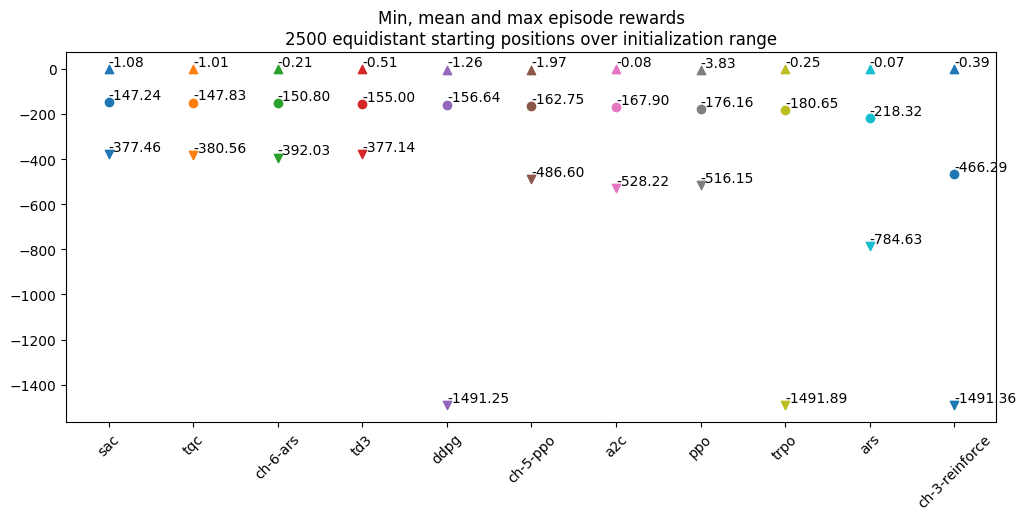

In [25]:
fig, ax1 = plt.subplots()
fig.set_figwidth(12)

# Plt1: Extract names and values
names = list(sorted_data.keys())
values = list(sorted_data.values())

# Create a consistent color mapping for names
unique_names = list(sorted_data.keys())  # Start with names from data1
colors = [plt.cm.tab10(i % 10) for i in range(len(unique_names))]
color_map = {name: colors[i] for i, name in enumerate(unique_names)}

for i, (name, value) in enumerate(sorted_data.items()):
    ax1.scatter(i, value[0], color=color_map[name], label=name, marker='v')
    ax1.scatter(i, value[1], color=color_map[name], label=name, marker='o')
    ax1.scatter(i, value[2], color=color_map[name], label=name, marker='^')
    # Add the value next to the point
    if value[1]:
        ax1.text(i, value[0], f"{value[0]:.2f}", fontsize=10, verticalalignment='bottom')
        ax1.text(i, value[1], f"{value[1]:.2f}", fontsize=10, verticalalignment='bottom')
        ax1.text(i, value[2], f"{value[2]:.2f}", fontsize=10, verticalalignment='bottom')

ax1.set_xticks(range(len(names)), names, fontsize=10, rotation=45)
ax1.set_title(f'Min, mean and max episode rewards\n{n_points_per_dim*n_points_per_dim} equidistant starting positions over initialization range')

### Visualize Reward for individual starting positions

In [38]:
print(f"Total initial states: {len(initial_states)}") 
print(f"First few states:\n{initial_states[:5]}")

Total initial states: 2500
First few states:
[[-3.14159265 -1.        ]
 [-3.01336438 -1.        ]
 [-2.88513611 -1.        ]
 [-2.75690784 -1.        ]
 [-2.62867957 -1.        ]]


In [ ]:
rewards = []
model, eval_env = exp_run.get_sb3_polynomial_model_and_eval_env(basis='chebyshev', env_name=deterministic_pendulum_env_name, coeffs=db['pendulum_chebyshev_ppo_best_agent_coeffs'], algo='ppo')
for s in initial_states:
    rewards.append(exp_run.run_sb3_model(model, eval_env, options={'x_init': s[0], 'y_init': s[1]})[0])
db['ch5ppo_deterministic_episode_results'] = rewards

Experiment ran for 6 minutes

In [15]:
ch_reward = db['ch5ppo_deterministic_episode_results']
ch_reward_ars = db['ch6ars_deterministic_episode_results']
results = db['huggingface_evaluation_results_pendulum_20251110']
rewards_by_algo = defaultdict(list)
for algo, _, reward in results:
    rewards_by_algo[algo].append(reward)
sac_reward = rewards_by_algo['sac']
ars_reward = rewards_by_algo['ars']
ppo_reward = rewards_by_algo['ppo']

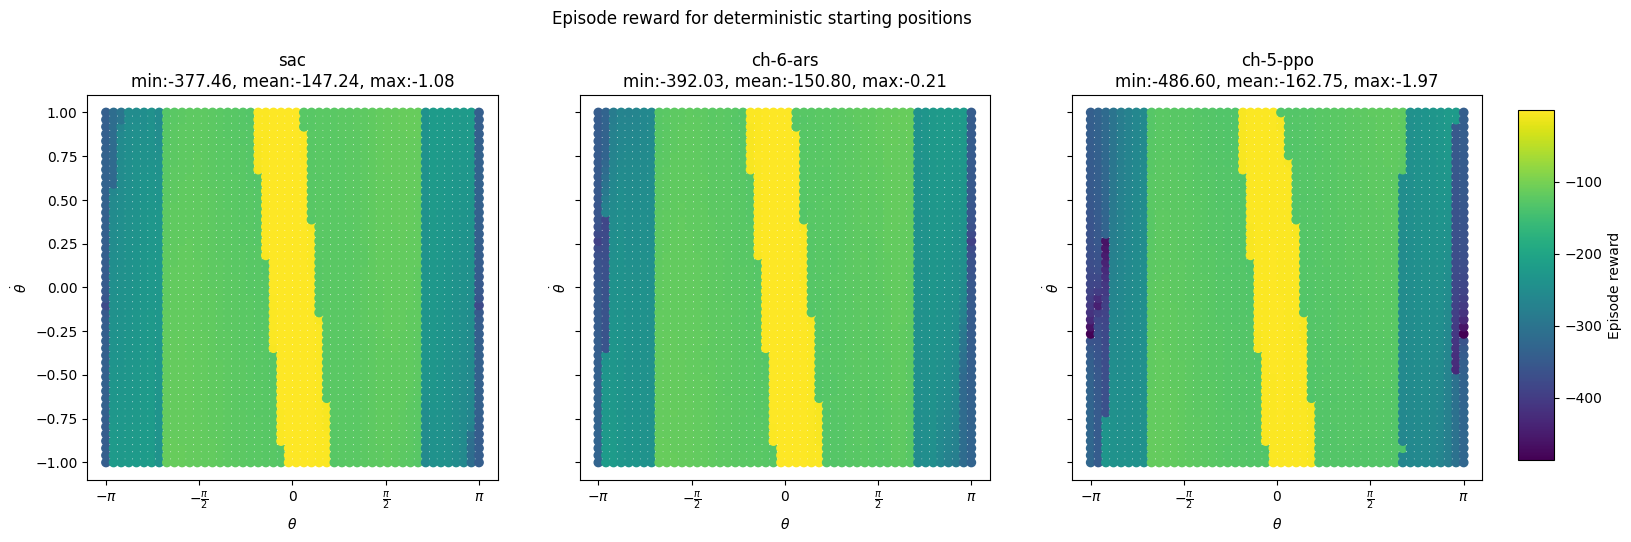

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

x = initial_states[:, 0]
y = initial_states[:, 1]

xticks = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
xtick_labels = [r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$']

vmin = min(min(sac_reward), min(ch_reward), min(ch_reward_ars))
vmax = max(max(sac_reward), max(ch_reward), max(ch_reward_ars))

sc1 = ax1.scatter(x, y, c=sac_reward, cmap='viridis', vmin=vmin, vmax=vmax)
ax1.set_xticks(xticks)
ax1.set_xticklabels(xtick_labels)
ax1.set_title(f'sac\nmin:{min(sac_reward):.2f}, mean:{np.mean(sac_reward):.2f}, max:{max(sac_reward):.2f}')
ax1.set_xlabel(r'$\theta$')
ax1.set_ylabel(r'$\dot{\theta}$')

sc2 = ax2.scatter(x, y, c=ch_reward_ars, cmap='viridis', vmin=vmin, vmax=vmax)
ax2.set_xticks(xticks)
ax2.set_xticklabels(xtick_labels)
ax2.set_title(f'ch-6-ars\nmin:{min(ch_reward_ars):.2f}, mean:{np.mean(ch_reward_ars):.2f}, max:{max(ch_reward_ars):.2f}')
ax2.set_xlabel(r'$\theta$')
ax2.set_ylabel(r'$\dot{\theta}$')

sc3 = ax3.scatter(x, y, c=ch_reward, cmap='viridis', vmin=vmin, vmax=vmax)
ax3.set_xticks(xticks)
ax3.set_xticklabels(xtick_labels)
ax3.set_title(f'ch-5-ppo\nmin:{min(ch_reward):.2f}, mean:{np.mean(ch_reward):.2f}, max:{max(ch_reward):.2f}')
ax3.set_xlabel(r'$\theta$')
ax3.set_ylabel(r'$\dot{\theta}$')

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  
fig.colorbar(sc2, cax=cbar_ax, label='Episode reward')
fig.suptitle('Episode reward for deterministic starting positions', y=1.05)

#plt.tight_layout()
plt.show()

Comparing SAC, CH-6-ARS and CH-5-PPO episode rewards w.r.t starting positions, we see a similar picture in the center, while SAC rewards are better at the outside boundaries

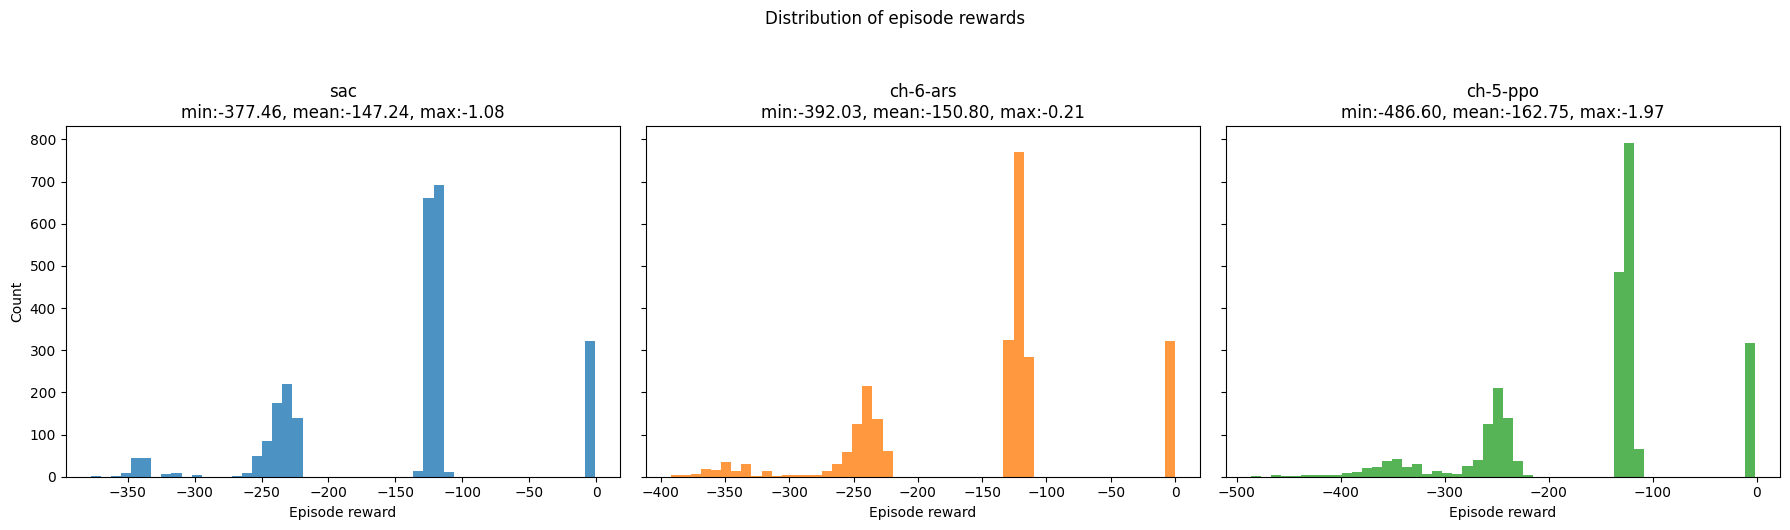

In [14]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

bins = 50  # adjust as needed

ax1.hist(sac_reward, bins=bins, color='tab:blue', alpha=0.8)
ax1.set_title(
    f'sac\nmin:{min(sac_reward):.2f}, '
    f'mean:{np.mean(sac_reward):.2f}, '
    f'max:{max(sac_reward):.2f}'
)
ax1.set_xlabel('Episode reward')
ax1.set_ylabel('Count')

ax2.hist(ch_reward_ars, bins=bins, color='tab:orange', alpha=0.8)
ax2.set_title(
    f'ch-6-ars\nmin:{min(ch_reward_ars):.2f}, '
    f'mean:{np.mean(ch_reward_ars):.2f}, '
    f'max:{max(ch_reward_ars):.2f}'
)
ax2.set_xlabel('Episode reward')

ax3.hist(ch_reward, bins=bins, color='tab:green', alpha=0.8)
ax3.set_title(
    f'ch-5-ppo\nmin:{min(ch_reward):.2f}, '
    f'mean:{np.mean(ch_reward):.2f}, '
    f'max:{max(ch_reward):.2f}'
)
ax3.set_xlabel('Episode reward')

fig.suptitle('Distribution of episode rewards', y=1.05)
plt.tight_layout()
plt.show()

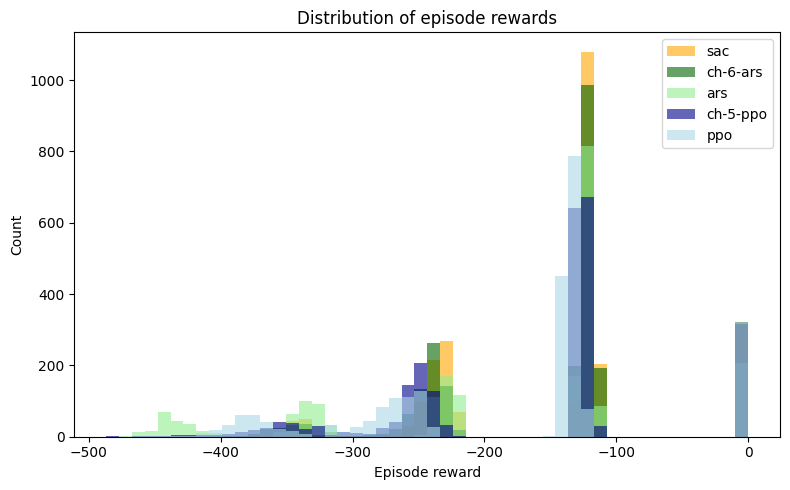

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

all_rewards = np.concatenate([sac_reward, ch_reward_ars, ch_reward])
bins = np.histogram_bin_edges(all_rewards, bins=50)

ax.hist(sac_reward, bins=bins, alpha=0.6, label='sac', color='orange')
ax.hist(ch_reward_ars, bins=bins, alpha=0.6, label='ch-6-ars', color='darkgreen')
ax.hist(ars_reward, bins=bins, alpha=0.6, label='ars', color='lightgreen')
ax.hist(ch_reward, bins=bins, alpha=0.6, label='ch-5-ppo', color='darkblue')
ax.hist(ppo_reward, bins=bins, alpha=0.6, label='ppo', color='lightblue')

ax.set_xlabel('Episode reward')
ax.set_ylabel('Count')
ax.set_title('Distribution of episode rewards')
ax.legend()

plt.tight_layout()
plt.show()

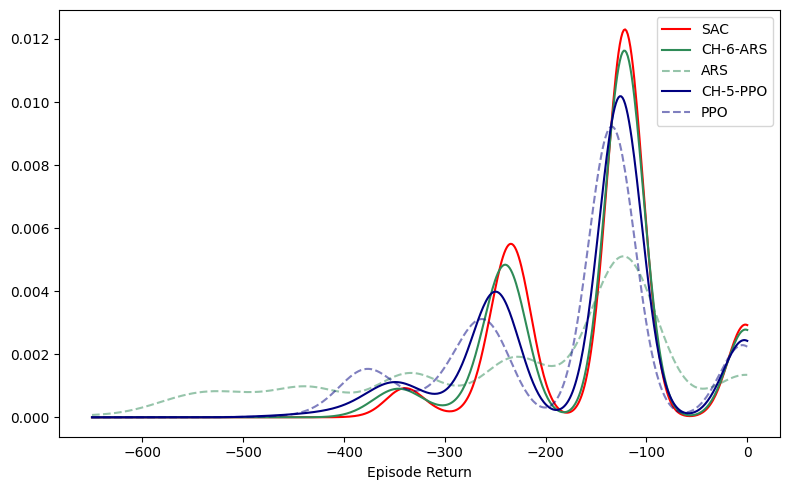

In [19]:
import numpy as np
from scipy.stats import gaussian_kde

all_rewards = np.concatenate([sac_reward, ch_reward_ars, ch_reward, ars_reward, ppo_reward])
minreward = np.min(all_rewards)
xs = np.linspace(-650, 0, 500)

kde_ch_sac = gaussian_kde(sac_reward)
kde_ch_ars = gaussian_kde(ch_reward_ars)
kde_ars = gaussian_kde(ars_reward)
kde_ch_ppo = gaussian_kde(ch_reward) # trust me, it is really ppo
kde_ppo = gaussian_kde(ppo_reward)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(xs, kde_ch_sac(xs), label='SAC', color='red')
ax.plot(xs, kde_ch_ars(xs), label='CH-6-ARS', color='seagreen')
ax.plot(xs, kde_ars(xs), '--', label='ARS', color='seagreen', alpha=.5)
ax.plot(xs, kde_ch_ppo(xs), label='CH-5-PPO', color='navy')
ax.plot(xs, kde_ppo(xs), '--', label='PPO', color='navy', alpha=.5)

ax.set_xlabel('Episode Return')
#ax.set_ylabel('Density')
#ax.set_title('Distribution of episode rewards')
ax.legend()

plt.tight_layout()
plt.show()
fig.savefig("pendulumreturndensity.pdf", bbox_inches='tight')

We can see that Chebyshev approximators push algorithms towards higher rewards.  

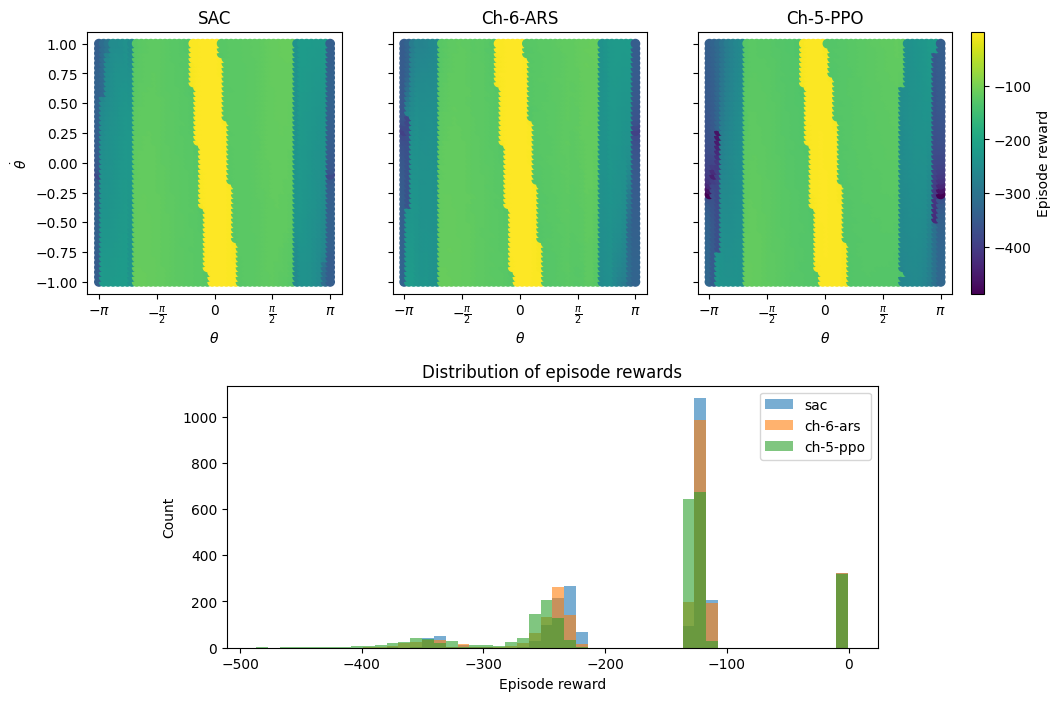

In [45]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(12, 8))
gs = GridSpec(2, 3, height_ratios=[1, 1], hspace=0.35, figure=fig)

# top row: share y-axis
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 2], sharey=ax1)

# bottom plot (no shared y)
ax4 = fig.add_subplot(gs[1, :])

x = initial_states[:, 0]
y = initial_states[:, 1]

xticks = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
xtick_labels = [r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$']

vmin = min(min(sac_reward), min(ch_reward), min(ch_reward_ars))
vmax = max(max(sac_reward), max(ch_reward), max(ch_reward_ars))

sc1 = ax1.scatter(x, y, c=sac_reward, cmap='viridis', vmin=vmin, vmax=vmax)
ax1.set_xticks(xticks)
ax1.set_xticklabels(xtick_labels)
ax1.set_title(f'SAC')
ax1.set_xlabel(r'$\theta$')
ax1.set_ylabel(r'$\dot{\theta}$')

sc2 = ax2.scatter(x, y, c=ch_reward_ars, cmap='viridis', vmin=vmin, vmax=vmax)
ax2.set_xticks(xticks)
ax2.set_xticklabels(xtick_labels)
ax2.tick_params(axis='y', which='both', labelleft=False)
ax2.set_title(f'Ch-6-ARS')
ax2.set_xlabel(r'$\theta$')
#ax2.set_ylabel(r'$\dot{\theta}$')

sc3 = ax3.scatter(x, y, c=ch_reward, cmap='viridis', vmin=vmin, vmax=vmax)
ax3.set_xticks(xticks)
ax3.set_xticklabels(xtick_labels)
ax3.tick_params(axis='y', which='both', labelleft=False)
ax3.set_title(f'Ch-5-PPO')
ax3.set_xlabel(r'$\theta$')
#ax3.set_ylabel(r'$\dot{\theta}$')

cbar = fig.colorbar(
    sc2,
    ax=[ax1, ax2, ax3],   # ONLY the top row
    label='Episode reward',
    location="right",
    pad=0.02,
    fraction=0.05
)

#fig.suptitle('Episode reward for deterministic starting positions', y=1.05)

all_rewards = np.concatenate([sac_reward, ch_reward_ars, ch_reward])
bins = np.histogram_bin_edges(all_rewards, bins=50)

ax4.hist(sac_reward, bins=bins, alpha=0.6, label='sac')
ax4.hist(ch_reward_ars, bins=bins, alpha=0.6, label='ch-6-ars')
ax4.hist(ch_reward, bins=bins, alpha=0.6, label='ch-5-ppo')

ax4.set_xlabel('Episode reward')
ax4.set_ylabel('Count')
ax4.set_title('Distribution of episode rewards')
ax4.legend()

pos = ax4.get_position()
new_width = 0.7 * pos.width
new_x0 = pos.x0 + 0.5 * (pos.width - new_width)  # center horizontally
ax4.set_position([new_x0, pos.y0, new_width, pos.height])

plt.show()
fig.savefig("pendulumrewards.pdf", bbox_inches='tight')

### Visualize policy

In [26]:
num_points_per_dim = 100

#Data
xss = np.linspace(-1, 1, num_points_per_dim)
yss = np.linspace(-1, 1, num_points_per_dim)
zss = np.linspace(-8, 8, num_points_per_dim)
zss_normed = np.linspace(-1, 1, num_points_per_dim)

X, Y, Z = np.meshgrid(xss, yss, zss)
X_normed, Y_normed, Z_normed = np.meshgrid(xss, yss, zss_normed)

X_flat = X.flatten()
Y_flat = Y.flatten()
Z_flat = Z.flatten()
points = np.column_stack((X_flat, Y_flat, Z_flat))

X_normed_flat = X_normed.flatten()
Y_normed_flat = Y_normed.flatten()
Z_normed_flat = Z_normed.flatten()
points_normed = np.column_stack((X_normed_flat, Y_normed_flat, Z_normed_flat))

In [ ]:
sac_model, sac_env = parallel.get_rl_zoo3_model_and_generate_env('sac', 'rl-trained-agents', 'Pendulum-v1')
ch_ars_model, ch_ars_env = exp_run.get_sb3_polynomial_model_and_eval_env(basis='chebyshev', env_name=deterministic_pendulum_env_name, coeffs=db['pendulum_chebyshev_ars_best_agent_coeffs'], algo='ars')
ch_ppo_model, ch_ppo_env = exp_run.get_sb3_polynomial_model_and_eval_env(basis='chebyshev', env_name=deterministic_pendulum_env_name, coeffs=db['pendulum_chebyshev_ppo_best_agent_coeffs'], algo='ppo')

vals_ch_ppo_unclipped = [ch_ppo_model.policy._predict(ch_ppo_model.policy.obs_to_tensor((p))[0], deterministic=True).detach().cpu() for p in points]
vals_ch_ars_unclipped = [ch_ars_model.policy.actor.policy.evaluate_point(torch.tensor(p, dtype=torch.float32)) for p in points]
vals_mlp_unclipped = [sac_model.policy._predict(torch.tensor([p], device='cuda:0', dtype=torch.float32)).detach().cpu() for p in points]

db['pendulum_ch_ppo_unclipped_vals'] = vals_ch_ppo_unclipped
db['pendulum_ch_ars_unclipped_vals'] = vals_ch_ars_unclipped
db['pendulum_mlp_sac_unclipped_vals'] = vals_mlp_unclipped

Experiment ran 30 minutes

In [ ]:
vals_ch_ppo_unclipped = db['pendulum_ch_ppo_unclipped_vals']
vals_ch_ars_unclipped = db['pendulum_ch_ars_unclipped_vals']
vals_mlp_unclipped = db['pendulum_mlp_sac_unclipped_vals']

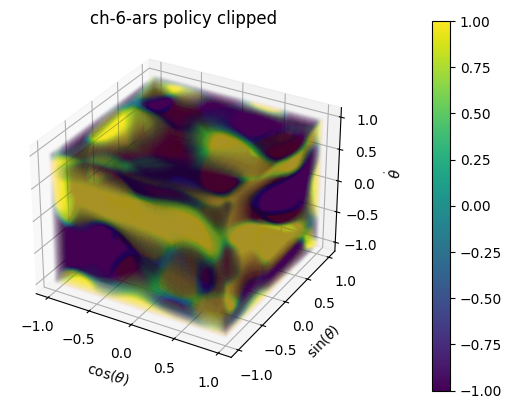

In [ ]:
plot_pendulum_policy(X_normed_flat, Y_normed_flat, Z_normed_flat, vals_ch_ars_unclipped, title='ch-6-ars policy clipped')

In [ ]:
plot_pendulum_policy(X_normed_flat, Y_normed_flat, Z_normed_flat, vals_ch_ppo_unclipped, title='ch-6-ppo policy clipped')


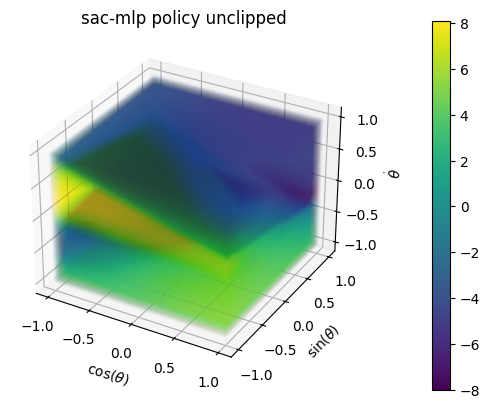

In [132]:
plot_pendulum_policy(X_flat, Y_flat, Z_normed_flat, vals_mlp_unclipped, title='sac-mlp policy unclipped')